In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (10,6)

%matplotlib inline

In [5]:
df = pd.read_csv("data/diabetes_uncleaned.csv")
print(df.shape)
df.head(10)

(768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [11]:
print(f"Duplicates: {df.duplicated().sum()}")

Duplicates: 0


No empty rows, all int64 type except BMI, DiabetesPedigreeFunction

No duplicated rows

In [29]:
zero_invalid = ["Glucose", "BloodPressure", "Insulin", "SkinThickness", "BMI"]
for col in zero_invalid:
    count = (df[col]==0).sum()
    pct = count/len(df) * 100
    print(f"{col} : {count}, ({pct}%)")

Glucose : 5, (0.6510416666666667%)
BloodPressure : 35, (4.557291666666666%)
Insulin : 374, (48.69791666666667%)
SkinThickness : 227, (29.557291666666668%)
BMI : 11, (1.4322916666666665%)


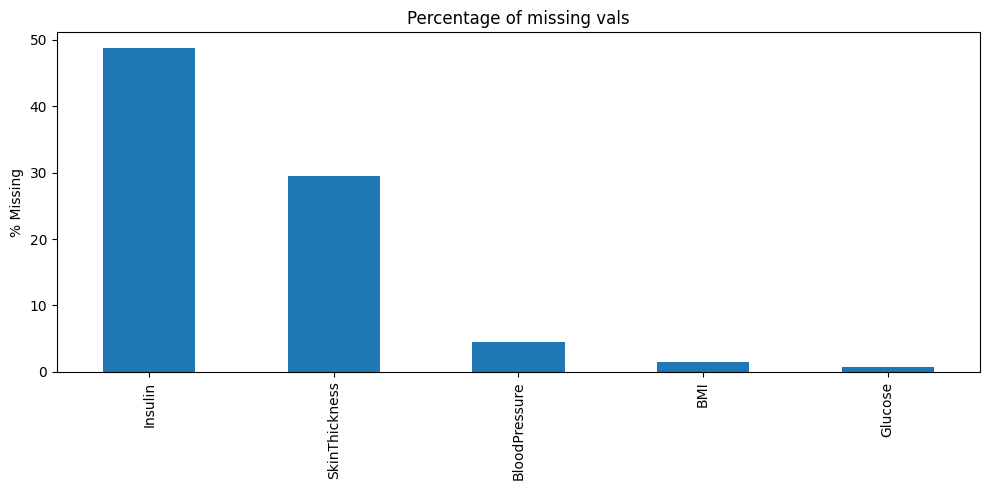

In [30]:
df_missing = df.copy()
for col in zero_invalid:
    df_missing[col] = df_missing[col].replace(0,np.nan)

fig, ax = plt.subplots(figsize = (10,5))
missing_pct = (df_missing.isnull().sum() / len(df_missing) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]
missing_pct.plot(kind = "bar", ax=ax)
ax.set_title("Percentage of missing vals")
ax.set_ylabel("% Missing")
plt.tight_layout()
plt.show()

Feature Distribution work:

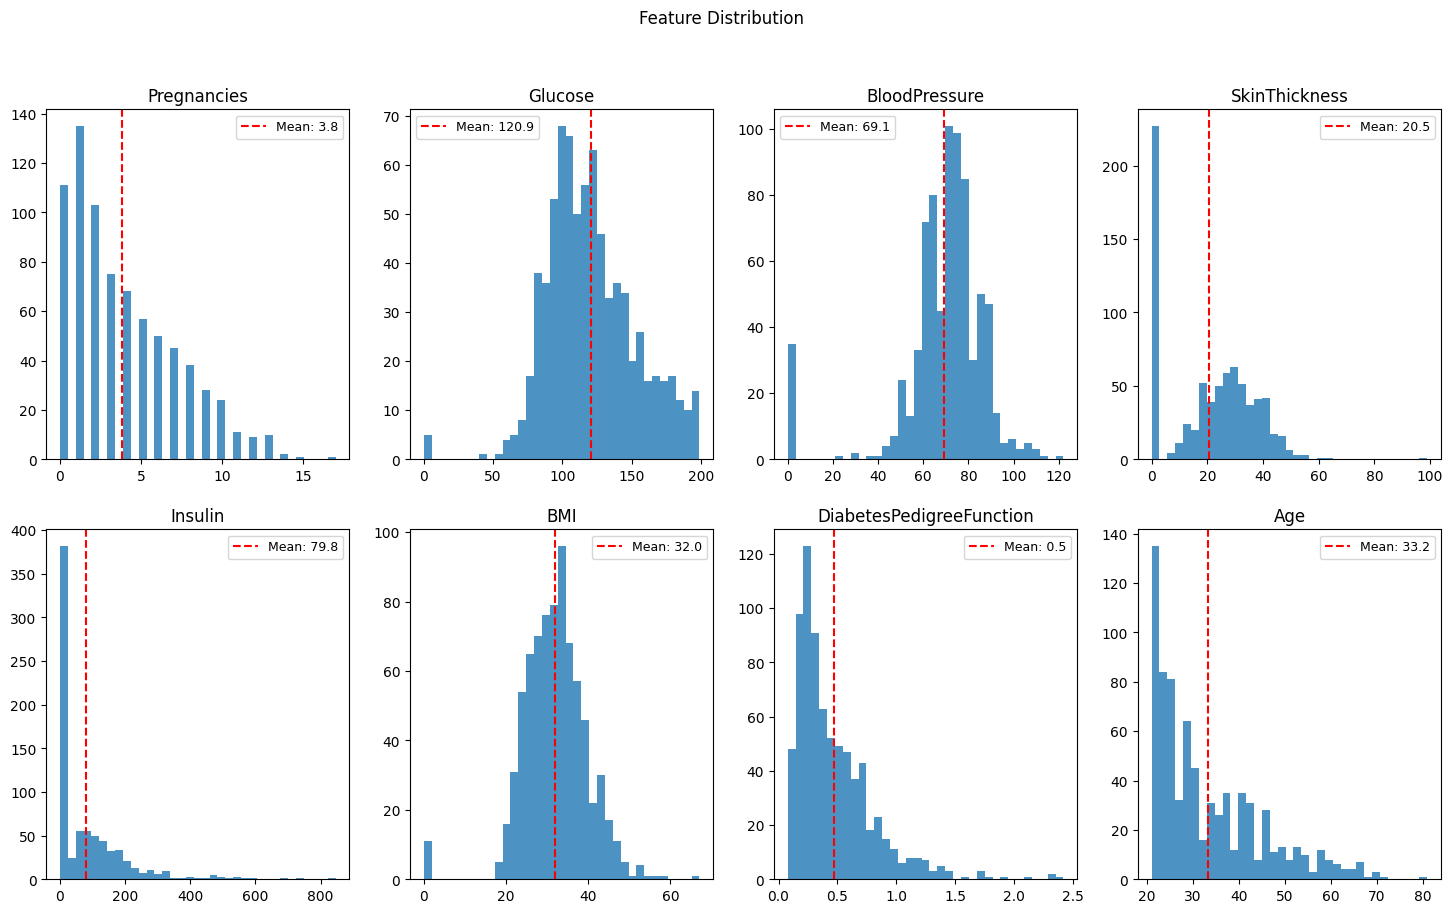

In [34]:
features = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"]

fig,ax = plt.subplots(2,4, figsize=(18,10))
ax = ax.flatten()

for i, col in enumerate(features):
    ax[i].hist(df[col], bins = 35, alpha = 0.8)
    ax[i].set_title(col)
    ax[i].axvline(df[col].mean(), color="red", linestyle="--", label=f"Mean: {df[col].mean():.1f}")
    ax[i].legend(fontsize=9)
    
plt.suptitle("Feature Distribution")
plt.show()

Spot Outliers:

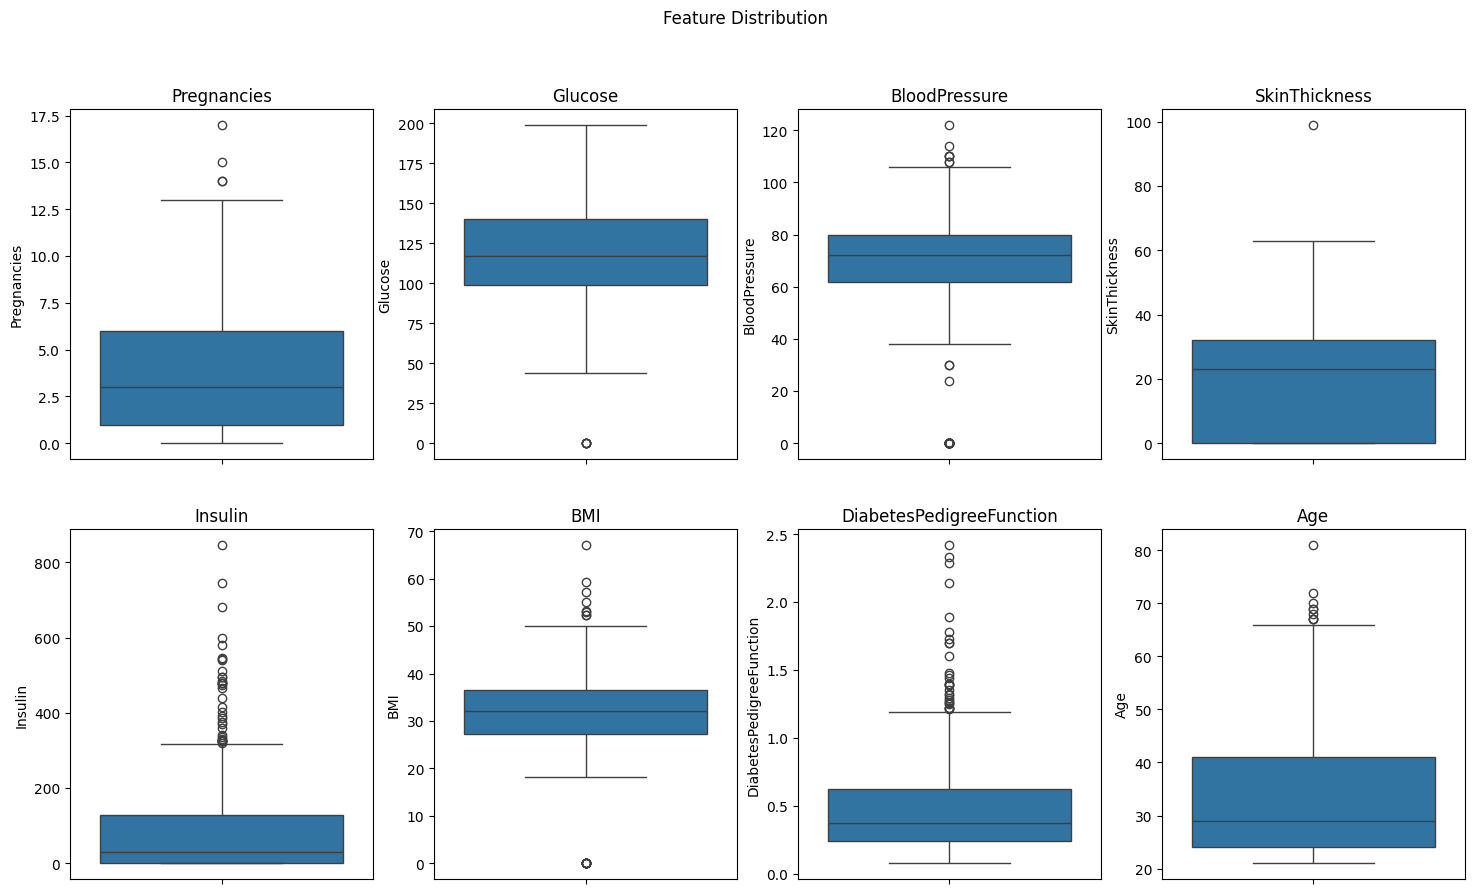

In [36]:
fig,ax = plt.subplots(2,4, figsize=(18,10))
ax =ax.flatten()

for i, col in enumerate(features):
    sns.boxplot(y=df[col], ax = ax[i])
    ax[i].set_title(col)

plt.suptitle("Feature Distribution")
plt.show()

Violin Plots for better distribution understanding:

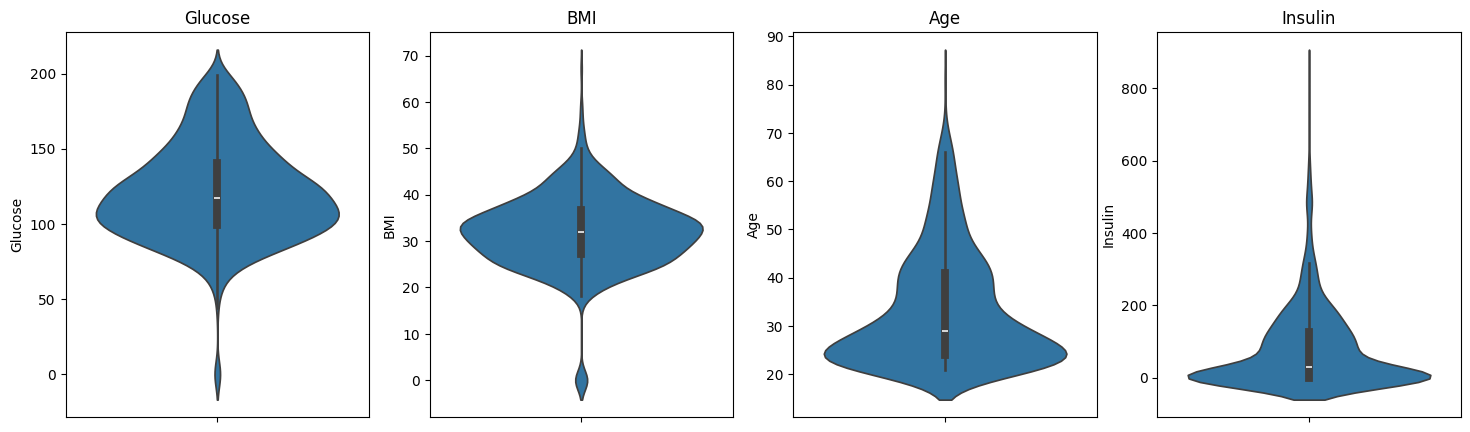

In [37]:
key_features = ["Glucose", "BMI", "Age", "Insulin"]
fig,ax = plt.subplots(1, 4, figsize=(18, 5))

for i, col in enumerate(key_features):
    sns.violinplot(y=col, data=df, ax=ax[i])
    ax[i].set_title(f"{col}")

plt.show()

Feature Distribution by Outcome

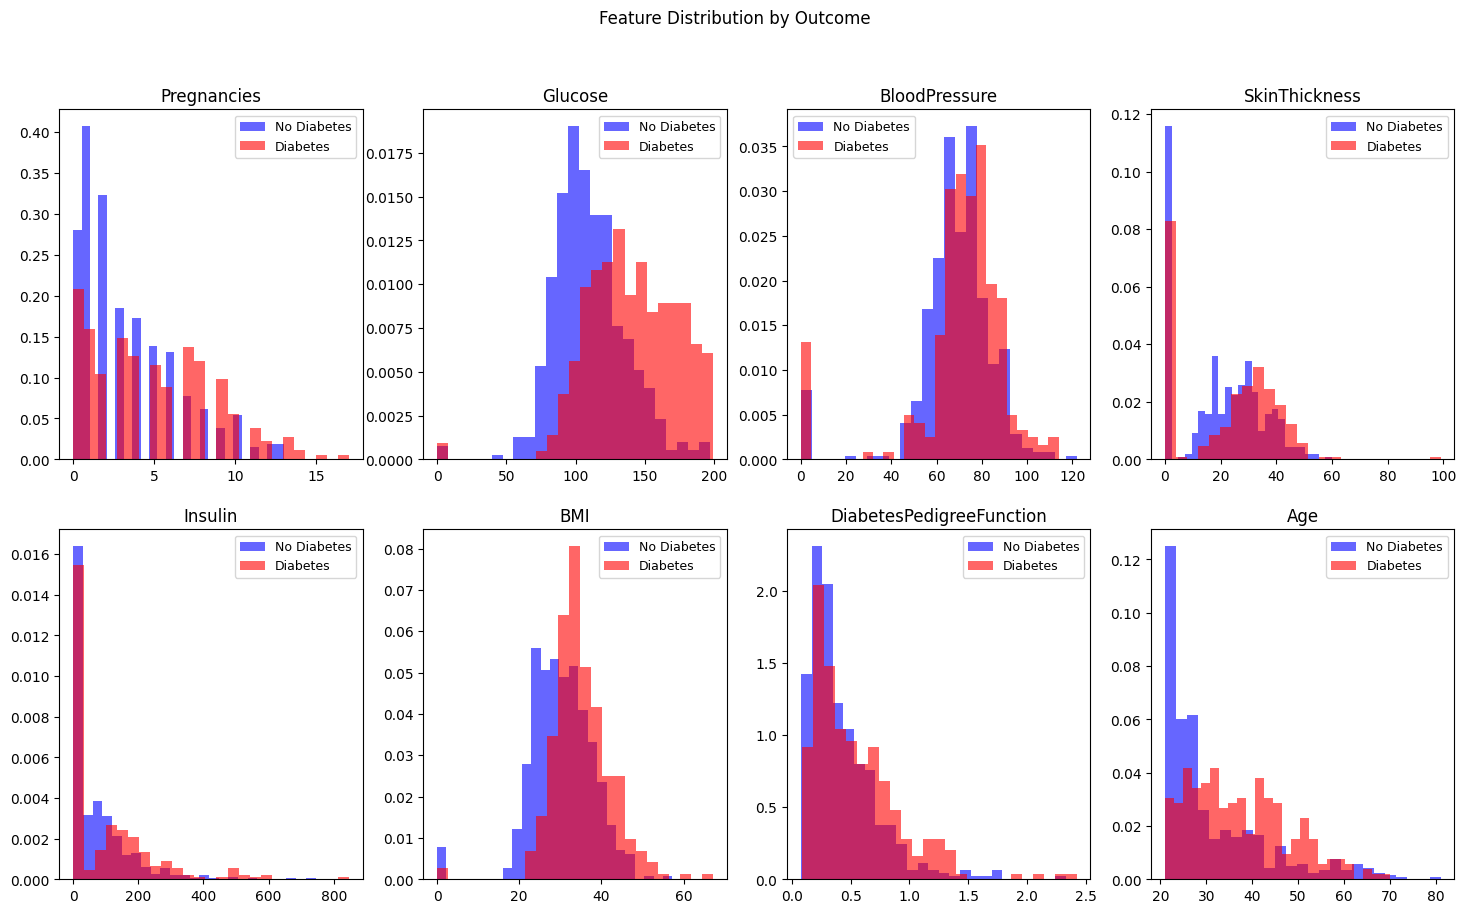

In [74]:
fig,ax = plt.subplots(2,4, figsize=(18,10))
ax = ax.flatten()

for i,col in enumerate(features):
    for outcome, label, color in [(0,"No Diabetes", "blue"),(1,"Diabetes", "red")]:
        subset = df[df["Outcome"]==outcome][col]
        ax[i].hist(subset, bins=25, alpha=0.6, color=color, label=label, density=True)
    ax[i].set_title(col)
    ax[i].legend(fontsize=9)

plt.suptitle("Feature Distribution by Outcome")
plt.show()

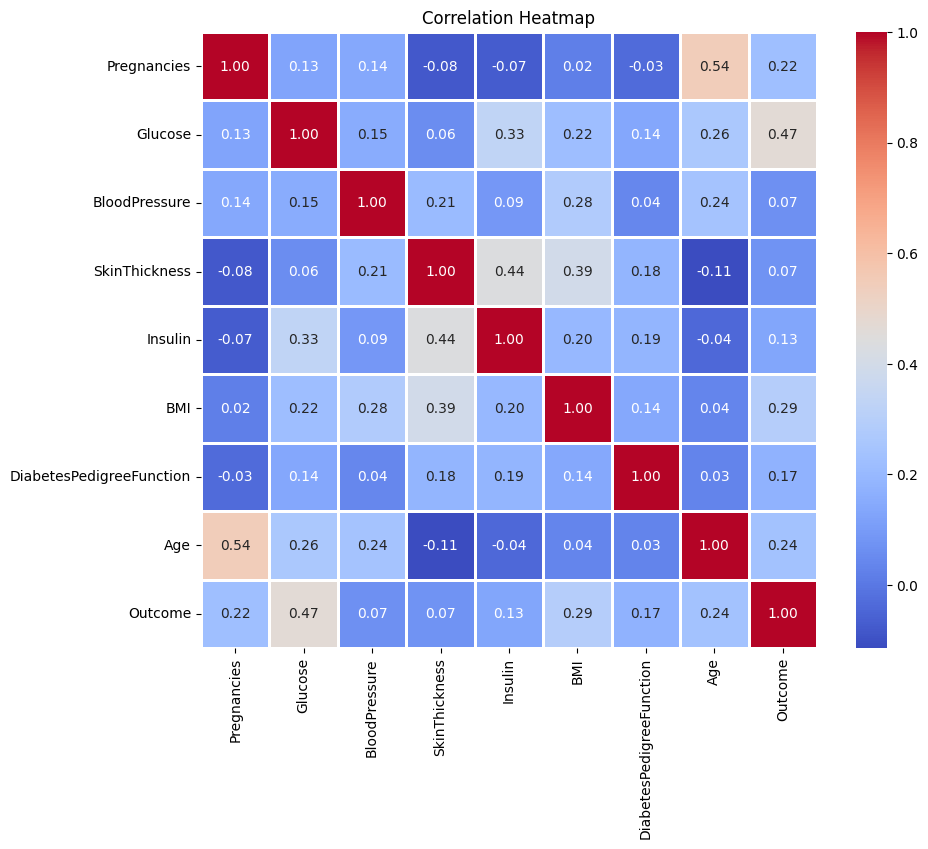

In [40]:
#Correlation Analysis
plt.figure(figsize=(10, 8))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True, linewidths=1)
#sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", square=True, linewidths=1)

plt.title("Correlation Heatmap")
plt.show()

Correlation with Outcome Results

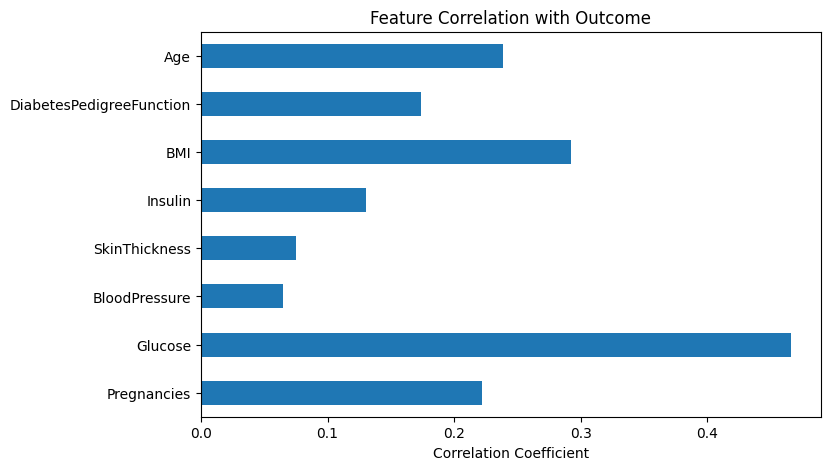

Feature Correlation with Outcome:
Pregnancies                 0.222
Glucose                     0.467
BloodPressure               0.065
SkinThickness               0.075
Insulin                     0.131
BMI                         0.293
DiabetesPedigreeFunction    0.174
Age                         0.238
Name: Outcome, dtype: float64


In [44]:
target_corr = df.corr()["Outcome"].drop("Outcome")

plt.figure(figsize=(8,5))
target_corr.plot(kind="barh")
plt.title("Feature Correlation with Outcome")
plt.xlabel("Correlation Coefficient")
plt.show()

print("Feature Correlation with Outcome:")
print(target_corr.round(3))

Diabetes by Age Group and Pregnancy

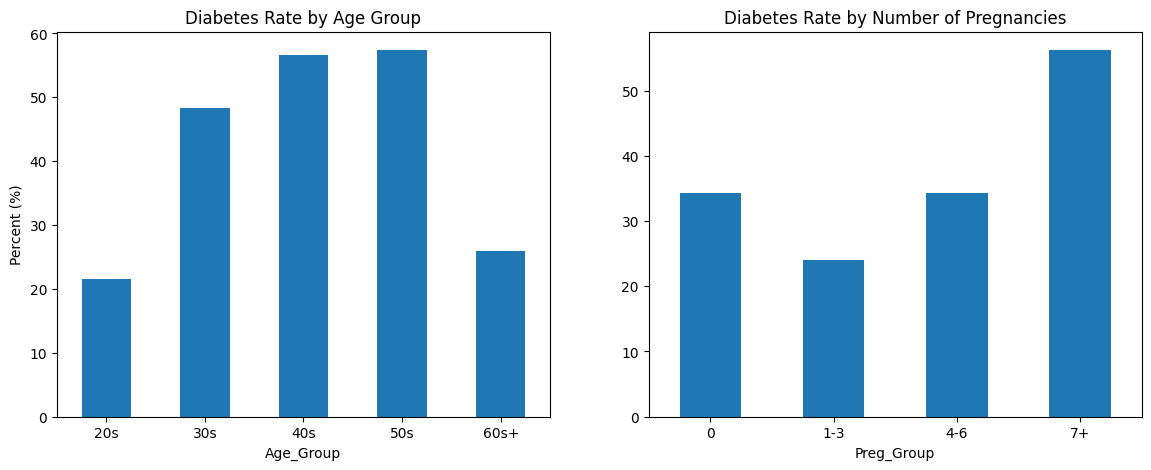

In [57]:
df["Age_Group"] = pd.cut(df["Age"], bins=[20, 30, 40, 50, 60, 90], labels=["20s", "30s", "40s", "50s", "60s+"])
fig,ax = plt.subplots(1,2, figsize=(14,5))

age_diabetes = df.groupby("Age_Group")["Outcome"].mean() * 100
age_diabetes.plot(kind = "bar", ax=ax[0])
ax[0].set_title("Diabetes Rate by Age Group")
ax[0].set_ylabel("Percent (%)")
ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=0)

df["Preg_Group"] = pd.cut(df["Pregnancies"], bins=[-1, 0, 3, 6, 20], labels=["0", "1-3", "4-6", "7+"])
preg_diabetes = df.groupby("Preg_Group")["Outcome"].mean() * 100
preg_diabetes.plot(kind = "bar", ax=ax[1])
ax[1].set_title("Diabetes Rate by Number of Pregnancies")
ax[0].set_ylabel("Percent (%)")
ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=0)

plt.show()

df.drop(columns=["Age_Group", "Preg_Group"], inplace=True)

Diabetes by Glucose and BMI Levels

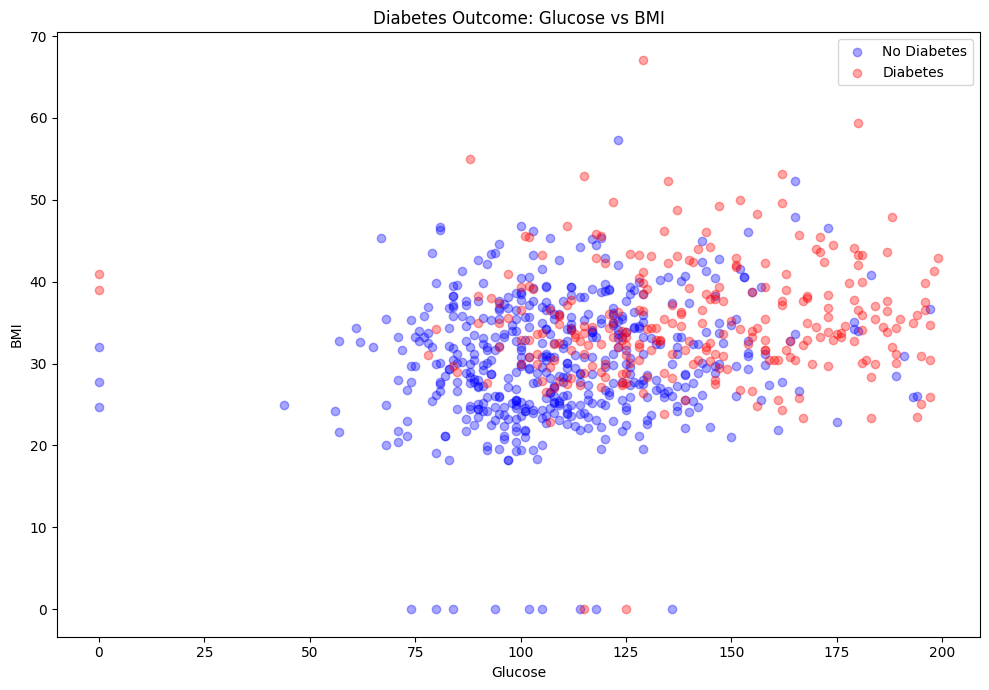

In [68]:
plt.figure(figsize=(10,7))
colors = {0: "blue", 1: "red"}
for outcome in [0,1]:
    subset = df[df["Outcome"]==outcome]
    plt.scatter(subset["Glucose"], subset["BMI"], c=colors[outcome], alpha=0.35, label="Diabetes" if outcome else "No Diabetes")

plt.xlabel("Glucose")
plt.ylabel("BMI")
plt.title("Diabetes Outcome: Glucose vs BMI")
plt.legend()
plt.tight_layout()
plt.show()

In [69]:
print("Diabetes by glucose level:")
print("-" * 40)

for label, low, high in [("Normal (<100)", 0, 100), ("Prediabetes (100-126)", 100, 126), ("Diabetes (>126)", 126, 300)]:
    subset = df[(df["Glucose"] >= low) & (df["Glucose"] < high)]
    rate = subset["Outcome"].mean() * 100
    print(f"{label}: {rate:.1f} (n={len(subset)})")

Diabetes by glucose level:
----------------------------------------
Normal (<100): 8.1 (n=197)
Prediabetes (100-126): 27.7 (n=274)
Diabetes (>126): 59.3 (n=297)


Key Findings:
- Class imbalance: 35% diabetic, 65% non-diabetic
- Missing Vals: Insulin, SkinThickness, BloodPressure, BMI, Glucose
- Biggest Missing Vals: Insulin, SkinThickness have most missing values (careful imputation)
- Glucose Correlation: Glucose has highest correlation with outcome (~47%)
- Positive Correlations: Diabetes more likely with increase of age, BMI, and number of pregnancies 
- Outliers: most outliers seen in Insulin and DiabetesPedigreeFunction
